In [1]:
import pandas as pd
import numpy as np
import datetime as dt
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from yellowbrick.cluster import SilhouetteVisualizer


import warnings
warnings.filterwarnings("ignore")

In [3]:
# Importando os dados, neste caso estamos avaliando os clientes de um cassino 
casino = pd.read_csv("data\Online_casino_DIB.csv")
# Começamos fazendo feature engineering, por exemplo, convertendo o objeto ReqTimeUTC para valores datetime
# Também cuidamos da limpeza dos dados, limpando dados fora do range desejado
casino.ReqTimeUTC = pd.to_datetime(casino.ReqTimeUTC)
casino = casino[casino.ReqTimeUTC <='2020-02-29 00:00:00+00:00'].copy()
casino.TransactionType = casino.TransactionType.map({'LOYALTYCARDDEBIT':'L2D', 'LOYALTYCARDCREDITCL':'L1D', 'LOYALTYCARDCREDIT':'L2W'})
casino = casino[(casino.TransactionType == "L2D") & (casino.Status=="APPROVED")].reset_index(drop=True)
casino = casino[['AccountIdentifier', 'ReqTimeUTC', 'TransactionAmount']]
casino = casino.sort_values(["AccountIdentifier", "ReqTimeUTC"]).reset_index(drop=True)
casino.rename(columns = {'AccountIdentifier':'customer', 'ReqTimeUTC':'timest',  'TransactionAmount':'amount'}, inplace=True)
casino.head()

,customer,timest,amount
0,customer1,2019-03-01 17:24:43+00:00,30.0
1,customer1,2019-03-01 19:54:04+00:00,50.0
2,customer1,2019-03-01 22:44:15+00:00,40.0
3,customer1,2019-03-02 02:44:20+00:00,100.0
4,customer1,2019-03-02 18:28:39+00:00,25.0


In [4]:
# Conferimos quantas entradas temos no dataset
# São mais de 69 mil entradas de 2280 clientes
print(len(casino))
print(len(casino.customer.unique()))


69734
2280


In [5]:
# Agora nosso objetivo é ultilizar todas as 69 mil entradas para estimar um perfil individual para cada um dos 2280 clientes

# Começando analisando há quanto tempo um individuo é cliente, quantas compras ele fez e qual foi a mais recente 
base_timestamp = pd.to_datetime("2020-03-01 00:00:00+00:00")

retention_ = casino.groupby("customer").agg(
    first_active_in_days = ('timest', lambda x: (base_timestamp - x.dt.floor("d").min()).days),
    last_active_in_days = ('timest', lambda x: (base_timestamp - x.dt.floor("d").max()).days),
    nr_purchases = ('timest', 'count')
    )
retention_ = retention_.reset_index()
retention_.head(3)

,customer,first_active_in_days,last_active_in_days,nr_purchases
0,customer1,366,2,444
1,customer10,364,2,1130
2,customer100,267,4,56


In [6]:
## Tambem avaliamos o total que cada cliente ja gastou com a empresa e o padrão de gastos deles
overall_spent = casino.groupby("customer").agg({'amount': ['sum', 'std']}).reset_index()
overall_spent.columns = overall_spent.columns.droplevel(0)
overall_spent.rename(columns={"": "customer"}, inplace=True)
overall_spent.head()

,customer,sum,std
0,customer1,34010.0,37.678533
1,customer10,32089.0,13.940103
2,customer100,1639.0,9.195831
3,customer1000,200.0,0.000000
4,customer1001,689.0,13.769130


In [7]:
# Analisamos a média de quanto cada cliente gasta por mês
casino['y_month'] = casino.timest.dt.to_period('M')
monthly_expenditure = casino.groupby(['customer', 'y_month'])['amount'].sum().reset_index()

monthly_average_spent = monthly_expenditure.groupby('customer')['amount'].mean().reset_index()
monthly_average_spent.rename(columns={'amount': 'm_avg_spent'}, inplace=True)
monthly_average_spent.head()

,customer,m_avg_spent
0,customer1,2834.166667
1,customer10,2674.083333
2,customer100,273.166667
3,customer1000,200.000000
4,customer1001,98.428571


In [8]:
# Resetando o index dos 3 dataframes criados até aqui

overall_spent = overall_spent.set_index("customer")
monthly_average_spent = monthly_average_spent.set_index("customer")
retention_= retention_.set_index("customer")

In [9]:
# Agora unimos todas as features que projetamos num dataframe unificado
customer_data = overall_spent.join([monthly_average_spent, retention_]).reset_index()
customer_data.head()

,customer,sum,std,m_avg_spent,first_active_in_days,last_active_in_days,nr_purchases
0,customer1,34010.0,37.678533,2834.166667,366,2,444
1,customer10,32089.0,13.940103,2674.083333,364,2,1130
2,customer100,1639.0,9.195831,273.166667,267,4,56
3,customer1000,200.0,0.000000,200.000000,300,300,2
4,customer1001,689.0,13.769130,98.428571,225,21,23


In [10]:
# Continuando com a limpeza de dados, vemos quantos dados invalidos existem no dataset
customer_data.isna().sum()

customer                  0
sum                       0
std                     845
m_avg_spent               0
first_active_in_days      0
last_active_in_days       0
nr_purchases              0
dtype: int64

In [11]:
# O problema é que muitos clientes só tem uma unica transação registrada
# Para limpar os valores invalidos gerados por isso, alteramos ele por um valor pequeno o suficiente pra não afetar o modelo praticamente
customer_data.loc[customer_data["std"].isna(), "std"] = 0.001
customer_data.loc[customer_data["std"] == 0] = 0.001
customer_data.head()

,customer,sum,std,m_avg_spent,first_active_in_days,last_active_in_days,nr_purchases
0,customer1,34010.000,37.678533,2834.166667,366.000,2.000,444.000
1,customer10,32089.000,13.940103,2674.083333,364.000,2.000,1130.000
2,customer100,1639.000,9.195831,273.166667,267.000,4.000,56.000
3,0.001,0.001,0.001000,0.001000,0.001,0.001,0.001
4,customer1001,689.000,13.769130,98.428571,225.000,21.000,23.000


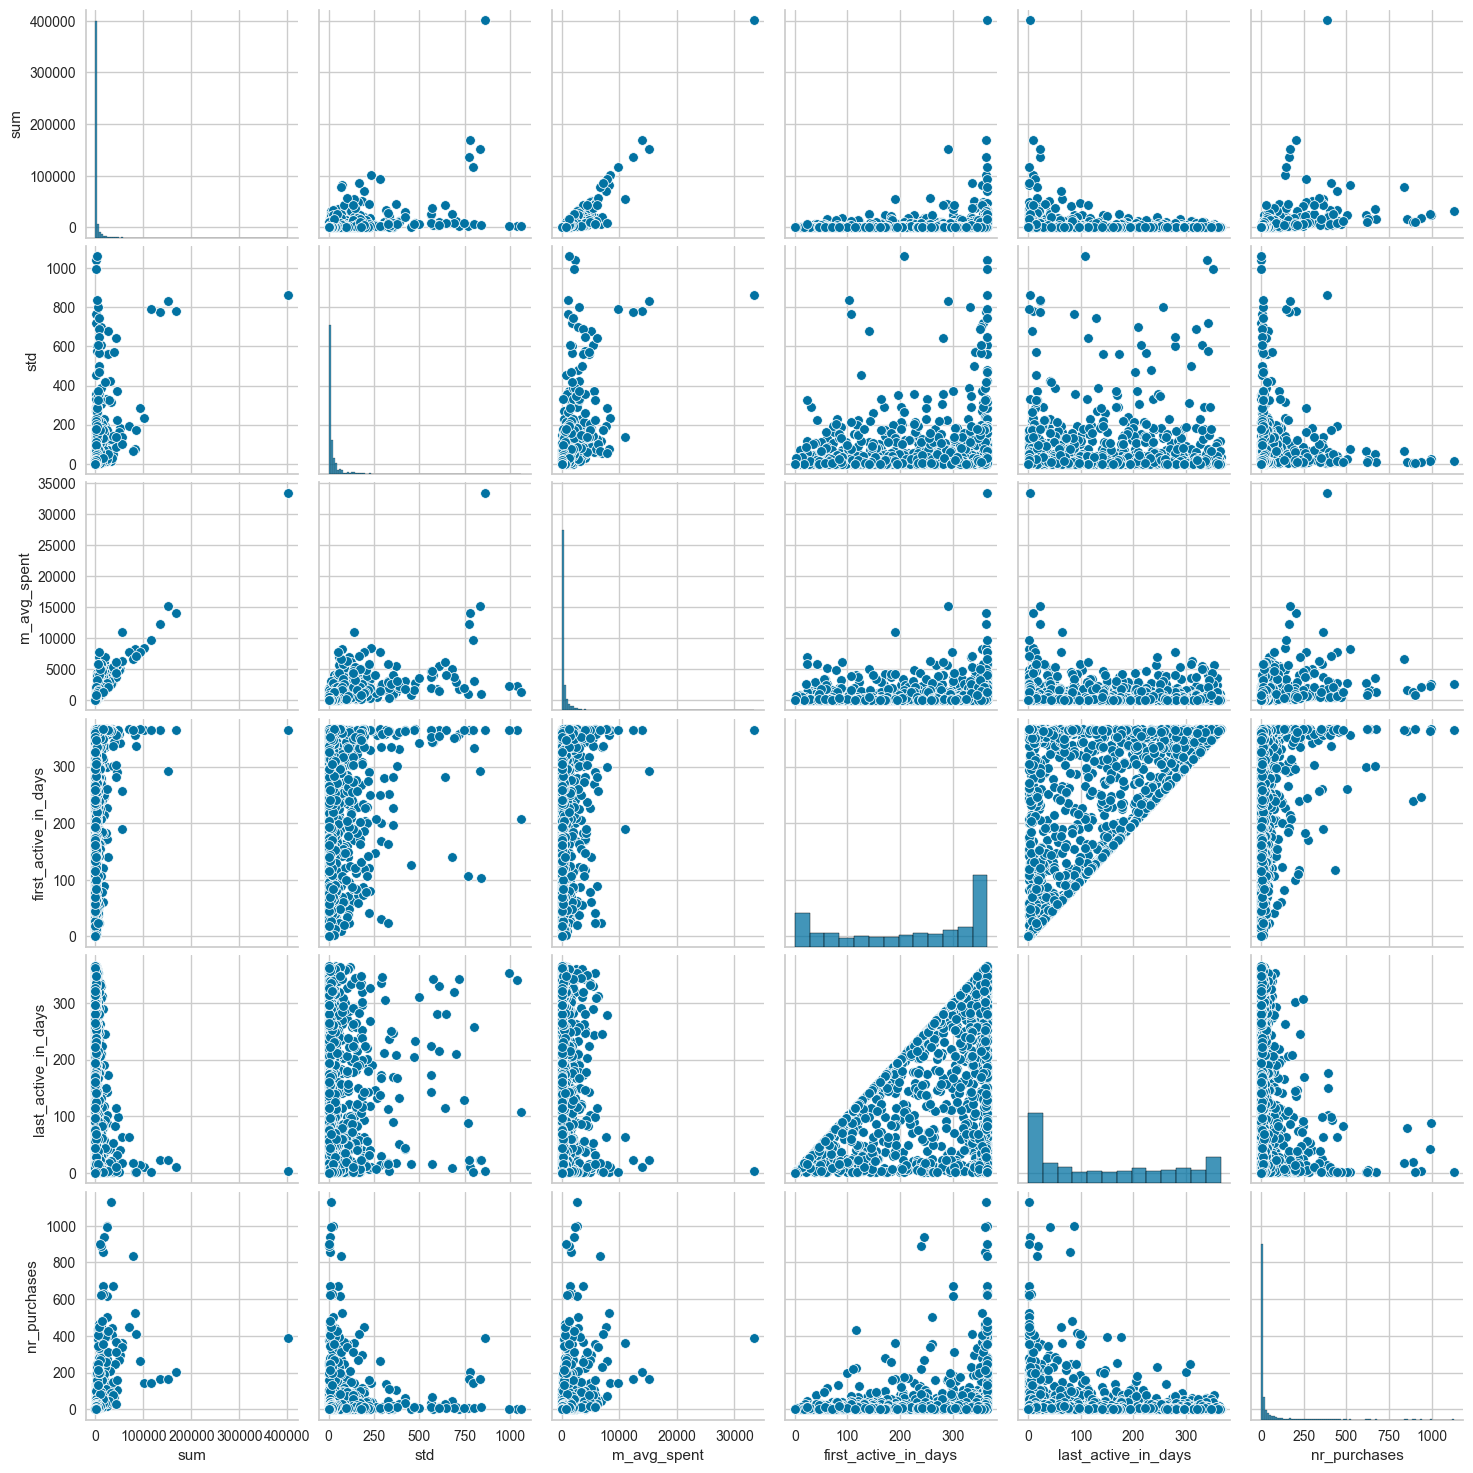

In [12]:
sns.pairplot(customer_data)

In [13]:
# Faremos uma analise de cluster sobre os dados
X = customer_data[['sum', 'std', 'm_avg_spent', 'first_active_in_days','last_active_in_days', 'nr_purchases']]

[351145738954.5724, 155757882907.15997, 75646849434.87233, 32115691613.23242, 23660547957.497803, 11957741793.71786]


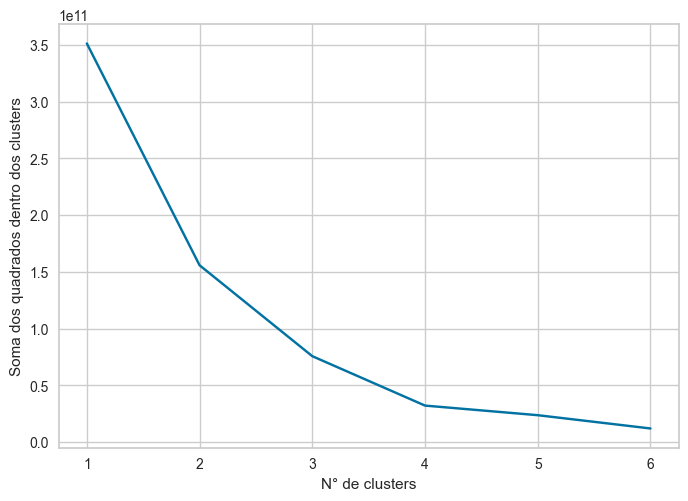

In [14]:
# Utilizaremos a técnica de K-Means Cluster
cluster = [1,2,3,4,5,6]
wcss_ls = []

for i in cluster:
    kmeans = KMeans(n_clusters = i)
    kmeans.fit(X)
    wcss = kmeans.inertia_ # Soma dos quadrados das distancias entre as amostras e o centro de clusters mais proximo
    wcss_ls.append(wcss)

# Para decidir quantos clusters usar (valor otimo de k), utilizamos o "metodo de cotovelo" (Elbow Method)
print(wcss_ls)
plt.plot(cluster, wcss_ls)
plt.xlabel('N° de clusters')
plt.ylabel('Soma dos quadrados dentro dos clusters')
plt.show()


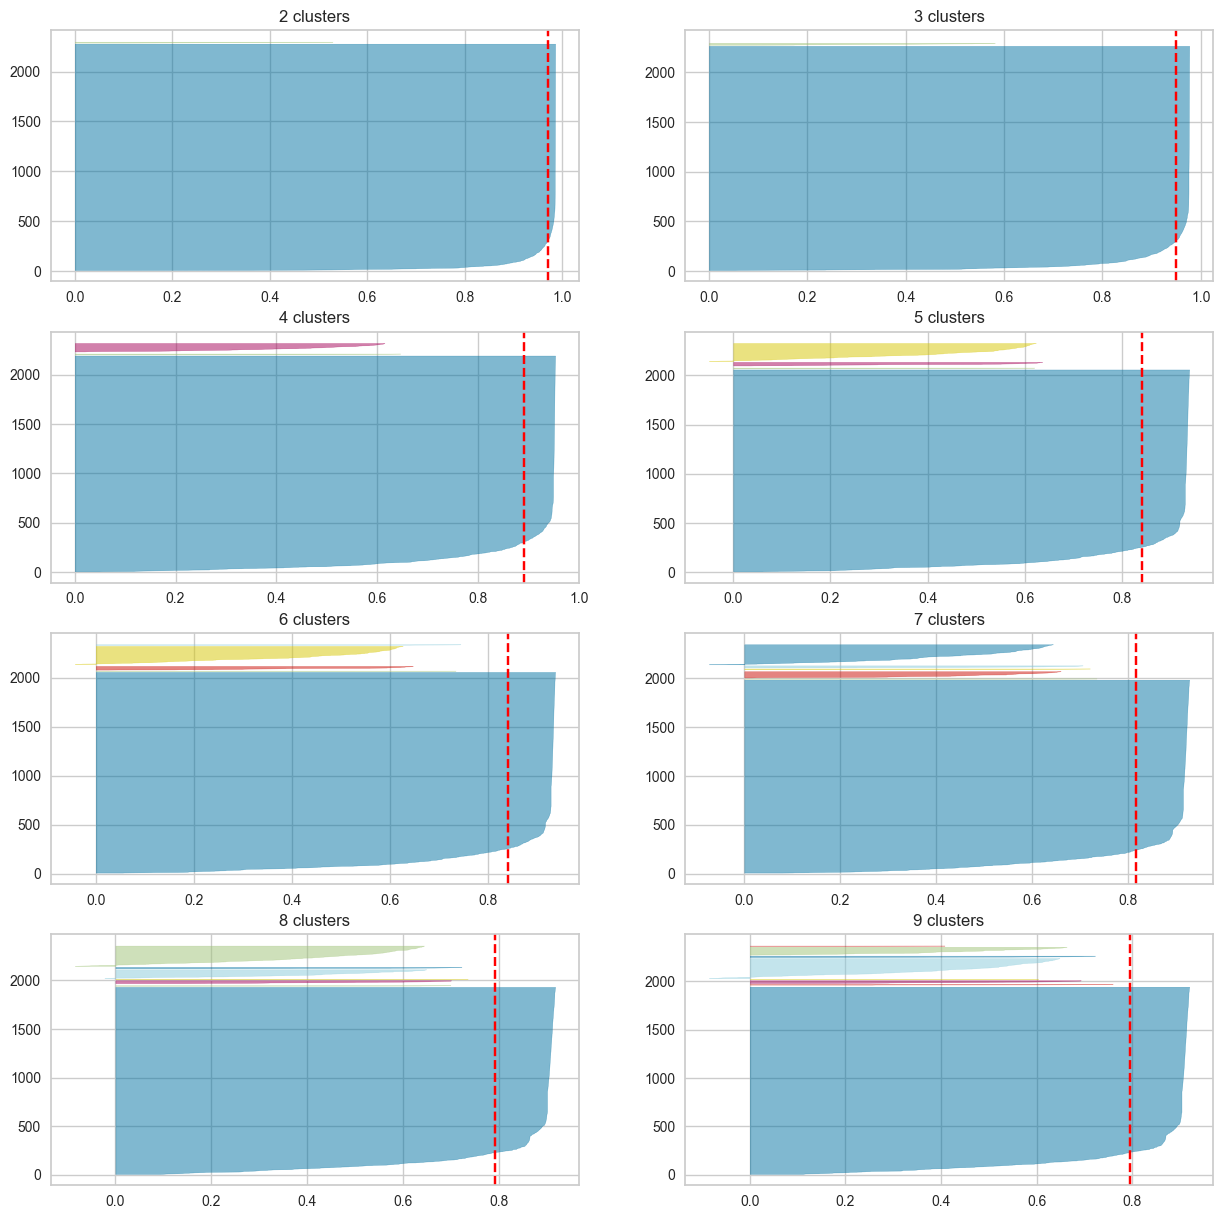

In [15]:
# Vizualizando os dados
# Apesar do metodo de cotovelo implicar que 2 clusters seriam ideais, os graficos contram outra história
# Um unico cluster domina os dados, até mesmo ultilizando 9 clusters

fig, ax = plt.subplots(4, 2, figsize=(15,15))

for i in [2, 3, 4, 5, 6,7,8,9]:

    km = KMeans(n_clusters=i, init='k-means++', n_init=10, max_iter=100, random_state=42)
    q, mod = divmod(i, 2)

    visualizer = SilhouetteVisualizer(km, colors='yellowbrick', ax=ax[q-1][mod])
    visualizer.fit(X)
    ax[q-1][mod].set_title(f"{i} clusters")

In [16]:
# Tentamos então aplicar uma função logaritica e técnicas de Hierarchical Clustering sobre os dados para ver se isso distribui melhor os clusters
X = customer_data[['sum', 'std', 'm_avg_spent', 'first_active_in_days','last_active_in_days', 'nr_purchases']]
X_std = np.log(X)

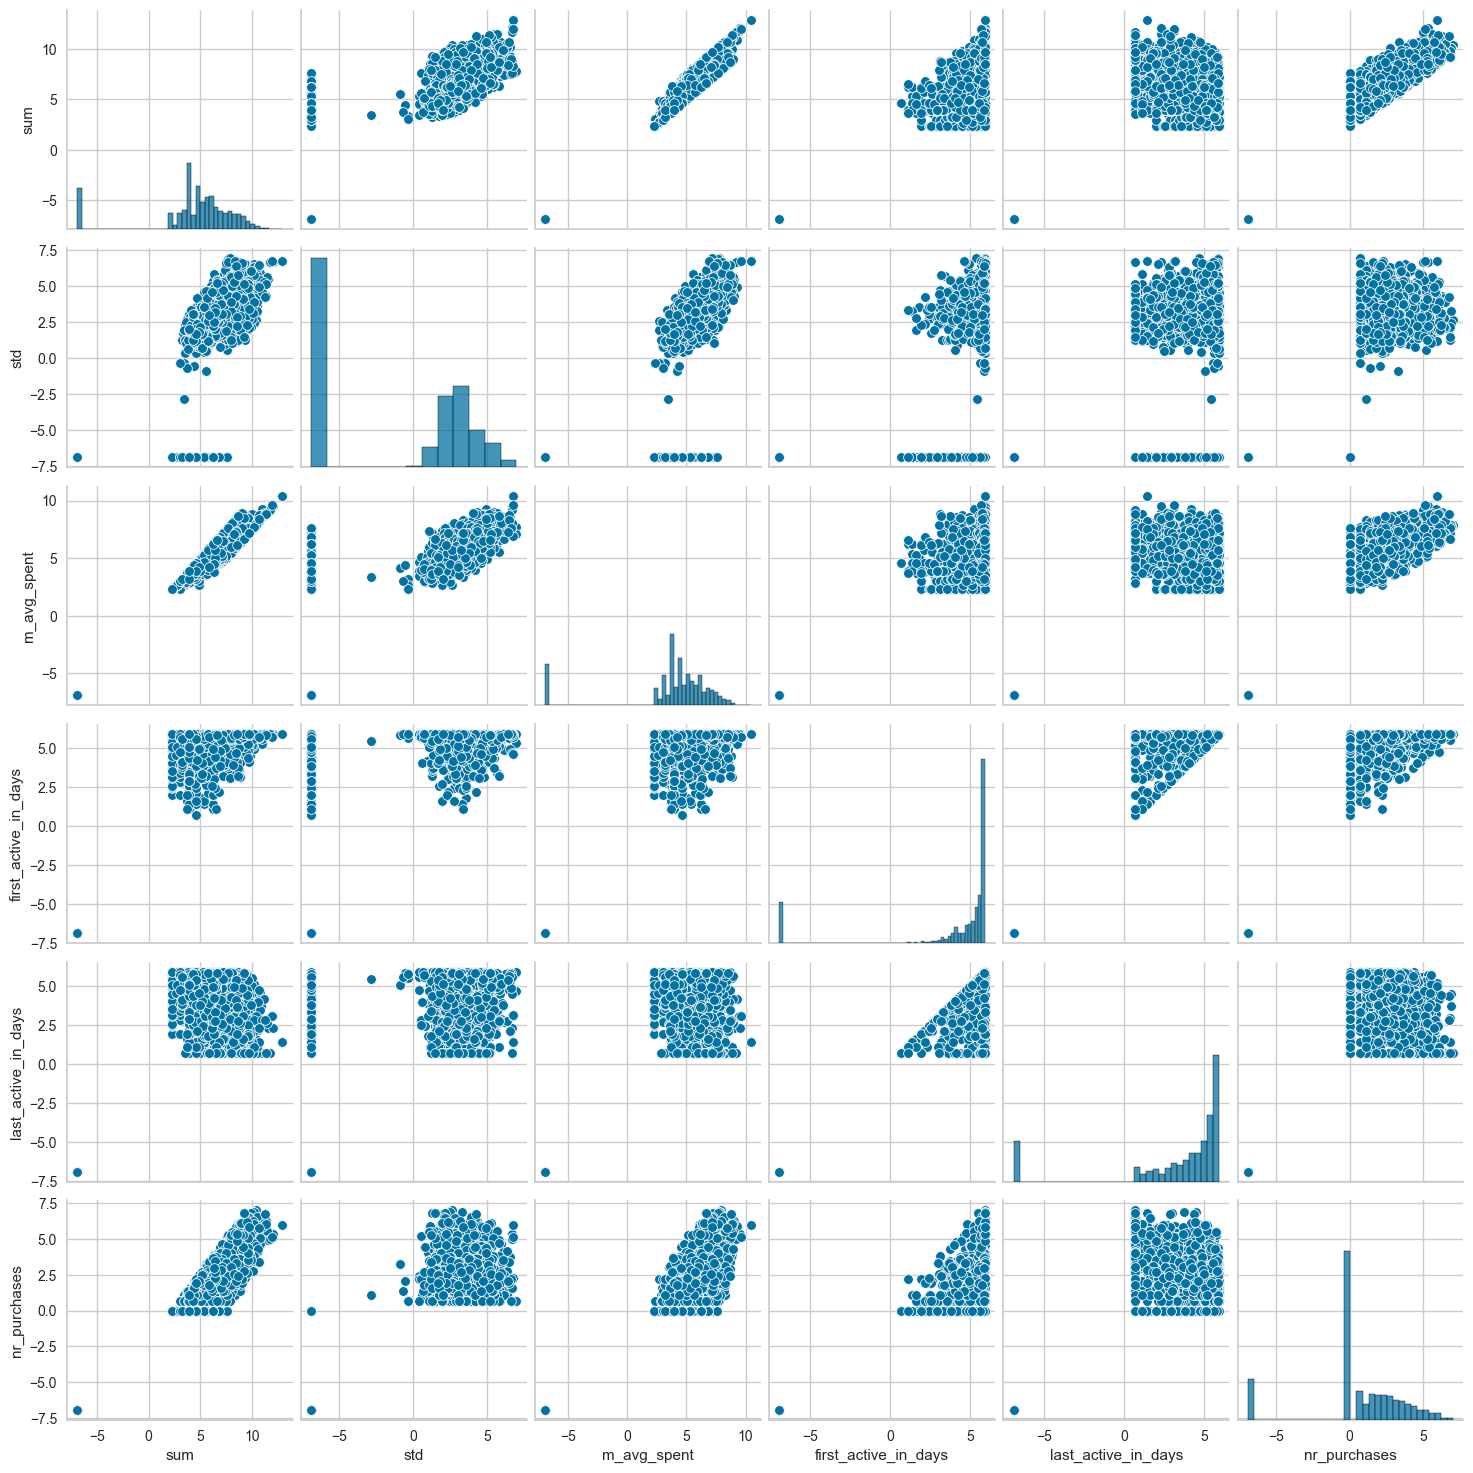

In [17]:
sns.pairplot(X_std)

[208369.09872861888, 112844.07351640191, 18815.592449415755, 12416.249458623884, 11335.331313632967, 9442.987706500302]


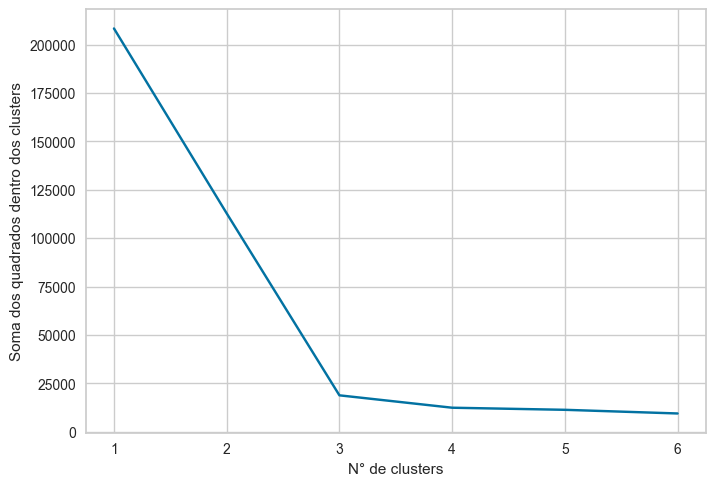

In [18]:
# Testando o metodo de cotovelo com os dados tratados novamente, ele agora sugere 3 clusters
cluster = [1,2,3,4,5,6]
wcss_ls = []

for i in cluster:
    kmeans = KMeans(n_clusters = i)
    kmeans.fit(X_std)
    wcss = kmeans.inertia_
    wcss_ls.append(wcss)
print(wcss_ls)
plt.plot(cluster, wcss_ls)
plt.xlabel('N° de clusters')
plt.ylabel('Soma dos quadrados dentro dos clusters')
plt.show()

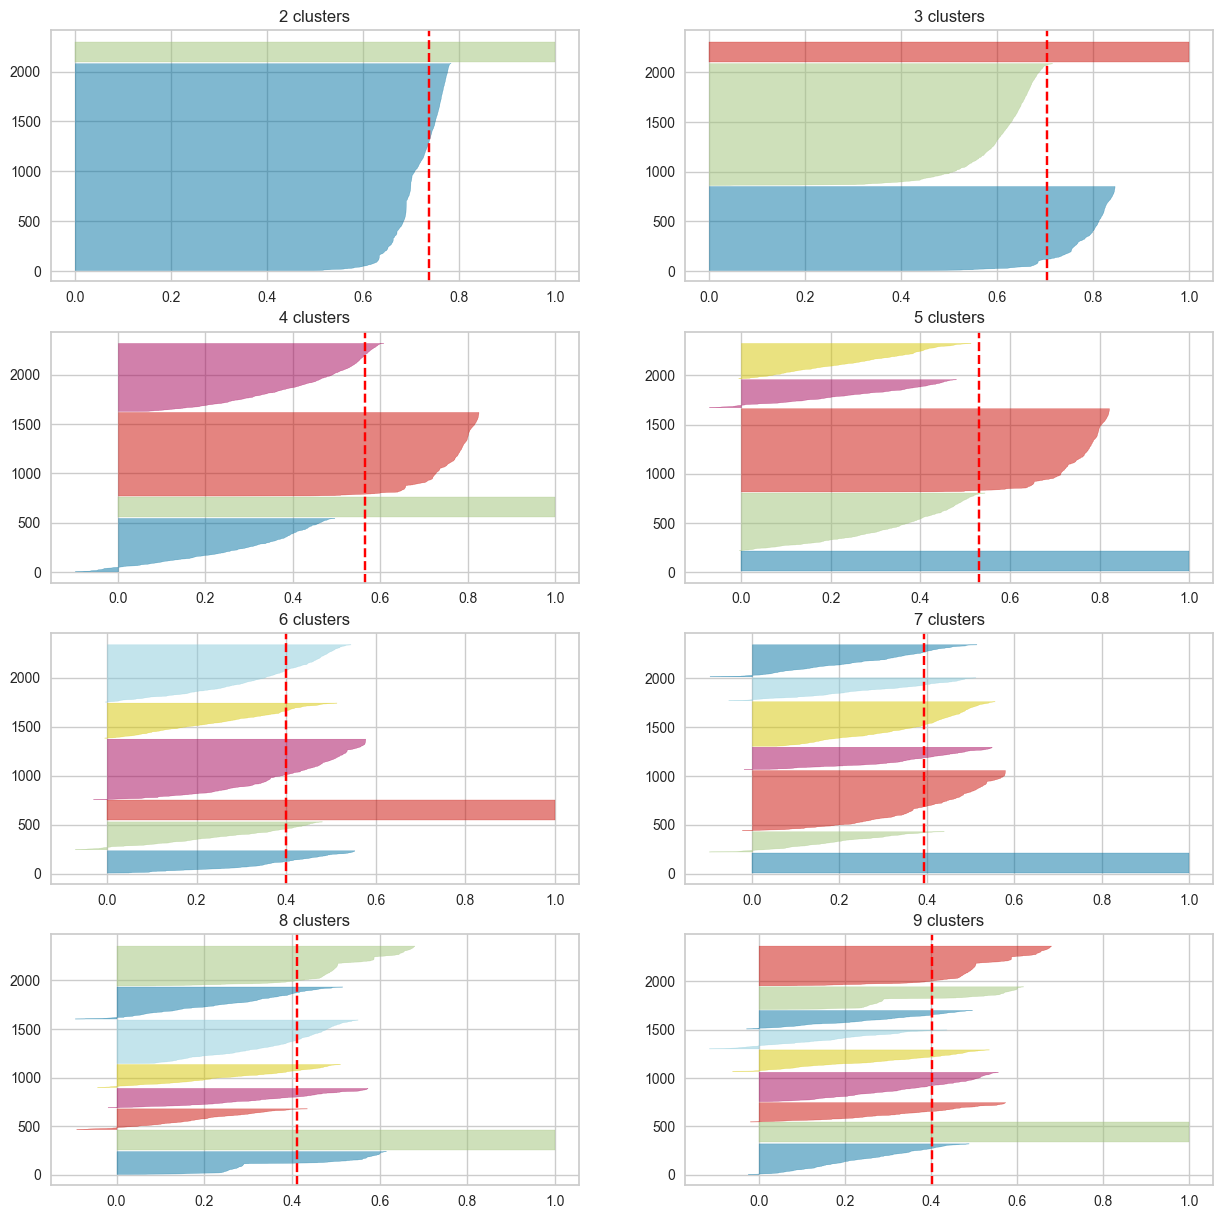

In [19]:
# Agora os dados são muito mais legiveis

fig, ax = plt.subplots(4, 2, figsize=(15,15))

for i in [2, 3, 4, 5, 6,7,8,9]:

    km = KMeans(n_clusters=i, init='k-means++', n_init=10, max_iter=100, random_state=42)
    q, mod = divmod(i, 2)

    visualizer = SilhouetteVisualizer(km, colors='yellowbrick', ax=ax[q-1][mod])
    visualizer.fit(X_std)
    ax[q-1][mod].set_title(f"{i} clusters")

In [20]:
# Seguiremos trabalhando com 3 clusters, avaliamos que temos um bom silhouette score
cluster_model = KMeans(n_clusters=3)
kmeans = cluster_model.fit(X_std)
silhouette_score(X_std, labels = kmeans.labels_)

0.7044985731905409

In [21]:
# Agora a tabela de clientes tambem informa de que grupo (cluster) eles fazem parte

customer_data['group'] = kmeans.labels_
customer_data

,customer,sum,std,m_avg_spent,first_active_in_days,last_active_in_days,nr_purchases,group
0,customer1,34010.000,37.678533,2834.166667,366.000,2.000,444.000,1
1,customer10,32089.000,13.940103,2674.083333,364.000,2.000,1130.000,1
2,customer100,1639.000,9.195831,273.166667,267.000,4.000,56.000,1
3,0.001,0.001,0.001000,0.001000,0.001,0.001,0.001,2
4,customer1001,689.000,13.769130,98.428571,225.000,21.000,23.000,1
...,...,...,...,...,...,...,...,...
2275,customer995,348.500,19.800042,69.700000,304.000,2.000,6.000,1
2276,customer996,50.000,7.637626,25.000000,353.000,170.000,3.000,1
2277,customer997,50.000,0.001000,50.000000,161.000,161.000,1.000,0
2278,0.001,0.001,0.001000,0.001000,0.001,0.001,0.001,2


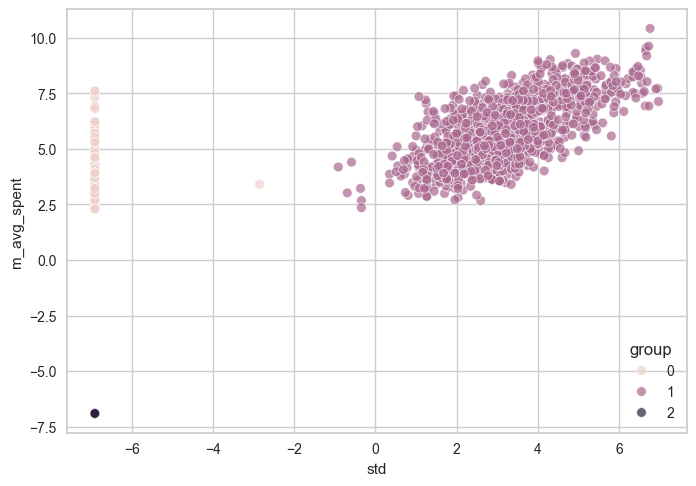

In [22]:
# Vamos agora vizualizar nossos clusters
fig, ax = plt.subplots()
sns.scatterplot(X_std, x = "std", y = "m_avg_spent", hue=customer_data['group'], alpha=0.7)
plt.show()

[0, 7, 54, 403, 2980, 22026, 162754]
[0, np.float64(0.02), np.float64(0.14), np.float64(1.0), np.float64(7.39), np.float64(54.6), np.float64(403.43)]


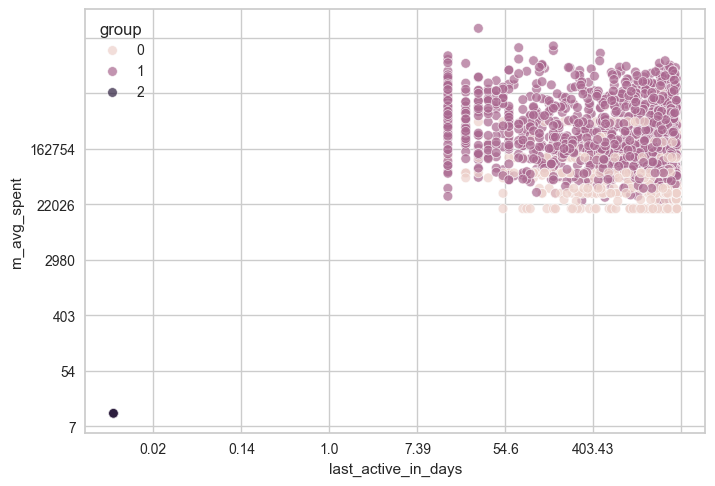

In [ ]:
# Melhorando a vizualização dos dados

fig, ax = plt.subplots()
sns.scatterplot(X_std, x = "last_active_in_days", y = "m_avg_spent", hue=customer_data['group'], alpha=0.7)

y = [0]
for i in np.arange(2,14,2):
    nr_int = int(np.exp(i))
    y.append(nr_int)
print(y)

x = [0]
for i in range(-4,7,2):
    nr_int = round(np.exp(i),2)
    x.append(nr_int)
print(x)
ax.set_xticklabels(x)
ax.set_yticklabels(y)
plt.show()

Notamos que o grupo 2 são os clientes que só fizeram uma transação com a empresa, a minoria de clientes no grupo 0 gastam um pouco menos por mês e a maioria dos clientes no grupo 1 tendem a usar o serviço com a mesma frequencia, mas o grupo 1 gasta muito mais e o grupo 0 utiliza os serviços com muito mais frequencia.